<a href="https://colab.research.google.com/github/michelle-lo/Sitcom-Topic-Modeling/blob/main/Brooklyn99_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-reqs

In [1]:
!pip install gensim
!pip install bertopic
!pip install bertopic[sentence-transformers]
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.0 MB/s eta 0:00:00


In [2]:
import re
import pandas as pd, json
import json, os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

import spacy
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
nlp = spacy.load("en_core_web_sm")

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases, TfidfModel
from gensim.models.phrases import Phraser

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import math

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from umap import UMAP
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Data

Source: https://github.com/atharva-naik/brooklyn99-dataset/tree/main/plain-text/season-1

Brief description of dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
data_path = "/content/drive/MyDrive/CSDS 601/dataset"

In [5]:
rows = []

for season in sorted(os.listdir(data_path)):

  season_path = os.path.join(data_path, season)
  if not os.path.isdir(season_path):
      continue

  for episode_file in sorted(os.listdir(season_path)):
      episode_path = os.path.join(season_path, episode_file)
      with open(episode_path, "r", encoding="utf-8") as f:
          episode = json.load(f)

      for line in episode:
        rows.append({
            "season": season,
            "episode": episode_file,
            "text": line
        })

df = pd.DataFrame(rows)
print(df.shape)
df

(83621, 3)


,season,episode,text
0,season-1,episode-1-Pilot.json,>This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.
...,...,...,...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.
83619,season-7,episode-9-Dillman.json,Who?


## Helper methods

In [6]:
def create_chunked_corpus(df, chunk_size, text_col='text'):
    chunks = []
    for (season, episode), group in df.groupby(["season", "episode"]):
        lines = group[text_col].tolist()
        for i in range(0, len(lines), chunk_size):
            chunk = " ".join(lines[i:i+chunk_size])
            if len(chunk.split()) > 5:
                chunks.append({
                    "season": season,
                    "episode": episode,
                    "text": chunk
                })
    return pd.DataFrame(chunks)

In [7]:
# building a comprehensive stop_words list

english_stopwords = set(stopwords.words("english"))
b99_stopwords = {
    # character names
    "jake", "peralta", "amy", "santiago", "rosa", "diaz",
    "charles", "boyle", "gina", "linetti", "raymond", "holt",
    "terry", "jeffords", "scully", "hitchcock",
    # dialogue words
    "yeah", "okay", "hey", "uh", "um", "gonna", "wanna",
    "got", "know", "like", "right", "oh", "well", "just",
    "said", "say", "go", "get", "one", "think", "yes",
    "no", "ok", "sure", "wait", "look", "come",
    "want", "need", "mean", "tell", "good", "really"
    # after testing
    "guy", "time", "thing", "man", "way", "little",
    "bad", "day", "people", "fine", "year", "let",
    "cool", "big", "wrong", "real", "new", "nice",
    "lot", "fun", "old", "ill", "thank", "great",
    "sorry", "charle", "first", "possible", "minute",
    "hour", "hell", "weird",
}

stop_words = english_stopwords.union(b99_stopwords)

## Data Cleaning

In [8]:
# Tuple of (pattern, replacement) pairs
clean_patterns = [
    (r"\[.*?\]", ""),    # remove stage directions [giggles]
    (r"\(.*?\)", ""),    # remove stage directions (laughs)
    (r"\b[A-Z]{2,}\b:", ""), # remove character directions e.g. PERALTA:
    (r"♪", ""),          # remove music symbols
    # Subtitle metadata
    # Matches sync/fixed/corrected metadata with separator (&amp; or and)
    (r"(?i)(sync(ed)?|fixed)\s*(&amp;|and)\s*(sync(ed)?|corrections?|corrected).*", ""),
    # Matches sync/fixed metadata without separator (e.g. "Sync corrections by", "Synchronized by")
    (r"(?i)(sync(ed|ronized)?|fixed)\s*(corrections?\s*by|by).*", ""),
    (r"(?i)\s*ripped\s*by\s*\S+.*", ""),
    # Remove the closing credits line
    (r"(?i)-?\s*not a doctor[.,]?\s*-?\s*shh[.!]?.*", ""),
    (r"^>+\s*", ""),    # remove leading > at start of line
]

def clean_text(text):
    for pattern, replacement in clean_patterns:
        text = re.sub(pattern, replacement, text)
    text = text.strip()  # remove leading/trailing whitespace
    return text

# Clean the data
df["clean_text"] = df["text"].apply(clean_text)

# Filter empty lines
df = df[df["clean_text"].str.replace(r"[^\w]", "", regex=True).str.len() > 0]

df

,season,episode,text,clean_text
0,season-1,episode-1-Pilot.json,>This job is eating me alive.,This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.,I'm not becoming like them.
...,...,...,...,...
83615,season-7,episode-9-Dillman.json,Well...,Well...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,","Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.,It's Sergeant Leslie Hunt-Minkoff.


In [9]:
def find_lines_containing(df, search_string, column="text"):
    mask = df[column].str.contains(search_string, case=False, na=False)
    results = df[mask]
    print(f"Found {len(results)} lines containing '{search_string}'")
    return results

find_lines_containing(df, "ripped by")

Found 2 lines containing 'ripped by'


,season,episode,text,clean_text
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...,I spent all these years trying to be the good ...
552,season-1,episode-1-Pilot.json,"Great work, team! Ripped By mstoll","Great work, team!"


In [10]:
df = df[['season', 'episode', 'clean_text']].copy().rename(columns={'clean_text': 'text'})
df

,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.
...,...,...,...
83615,season-7,episode-9-Dillman.json,Well...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.


# LDA

For LDA, [insert reason why longer documents are better] we use episodes since it works better on longer documents with more diverse set of vocabulary. blah *blah*

1. Lowercase everything
2. Remove whitespace, punctuation, numbers
3. Tokenize
4. Remove stop words (english stop words, show sepcific words like character names and fillter dialogue words)
5. Lemmatize (keep to roots) vs stemming
6. Filter by token length and frequency, and then filter extremes
7. Build Bag of Words

## Baseline LDA

In [ ]:
lda_df = (
    df.groupby(["season", "episode"])["text"]
    .apply(lambda lines: " ".join(lines))
    .reset_index()
)

print(f"Total episodes:", len(lda_df))
lda_df.head()

Total episodes: 134


,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive. I can't breathe a...
1,season-1,episode-10-Thanksgiving.json,- Happy Turkey Day. - Yes! Right out of the ga...
2,season-1,episode-11-Christmas.json,"all right, you take the skinny one on the righ..."
3,season-1,episode-12-Pontiac_Bandit.json,He's here. Boyle's here. This is so fun! I wis...
4,season-1,episode-13-The_Bet.json,"charles, this is exciting. Medal of valor. I k..."


In [ ]:
def preprocess_for_lda(text):
  # make lowercase and remove punctuation
  text = text.lower()
  text = re.sub(r"[^a-z\s]", "", text)

  # lemmatize and filter via spaCy
  docs = nlp(text)
  tokens = [
      token.lemma_ for token in docs
      if token.is_alpha # letters only
      and token.lemma_ not in stop_words # and not a stop word
      and len(token.lemma_) > 2 # longer than 2 characters (like to, an, ok)
      and token.lemma_ != "-PRON-" # like he, she, they
  ]
  return tokens

# Preprocess episodes for LDA
lda_docs = [preprocess_for_lda(text) for text in lda_df["text"]]

lda_docs[1][:20]

KeyboardInterrupt: 

In [ ]:
dictionary = corpora.Dictionary(lda_docs)

dictionary.filter_extremes(
  no_below=5, # words must appear in at least 2 episodes
  no_above=0.8, # words can't appear in more than 80% of episodes
  keep_n=10000
)

# convert into bag of words
corpus = [dictionary.doc2bow(doc) for doc in lda_docs]

print(f"Dictionary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

lda_docs[1][:20]

Dictionary size: 3225
Corpus size: 134


ValuesView(<gensim.corpora.dictionary.Dictionary object at 0x7d4d8eedc830>)

In [ ]:
# training the LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    passes=10,
    random_state=42
)

for idx, topic in lda_model.print_topics(num_words=10):
  print(f"Topic {idx}: {topic}")

Topic 0: 0.005*"detective" + 0.004*"dog" + 0.004*"phone" + 0.004*"baby" + 0.004*"room" + 0.004*"boy" + 0.004*"drug" + 0.003*"lie" + 0.003*"lose" + 0.003*"precinct"
Topic 1: 0.004*"party" + 0.004*"kevin" + 0.004*"meet" + 0.004*"detective" + 0.004*"care" + 0.003*"teddy" + 0.003*"phone" + 0.003*"cop" + 0.003*"fire" + 0.003*"whoa"
Topic 2: 0.007*"heist" + 0.006*"win" + 0.005*"watch" + 0.004*"baby" + 0.004*"cop" + 0.004*"team" + 0.003*"halloween" + 0.003*"bet" + 0.003*"steal" + 0.003*"detective"
Topic 3: 0.005*"night" + 0.004*"cop" + 0.004*"dad" + 0.004*"sarge" + 0.004*"solve" + 0.004*"weird" + 0.003*"kid" + 0.003*"detective" + 0.003*"play" + 0.003*"room"
Topic 4: 0.011*"debbie" + 0.007*"figgis" + 0.006*"larry" + 0.006*"greg" + 0.005*"phone" + 0.004*"person" + 0.004*"gun" + 0.004*"course" + 0.004*"ninenine" + 0.004*"jean"
Topic 5: 0.006*"cheddar" + 0.006*"jimmy" + 0.005*"truck" + 0.005*"belt" + 0.005*"heist" + 0.004*"fbi" + 0.004*"whoa" + 0.004*"number" + 0.004*"file" + 0.004*"win"
Topic 6:

In [ ]:
coherence_model = CoherenceModel(
    model=lda_model,
    texts=lda_docs,
    dictionary=dictionary,
    coherence="c_v"
)

print(f"Coherence Score: {coherence_model.get_coherence()}")

Coherence Score: 0.23497335705919548


Topics: 30, Coherence: 0.2563
Topics: 35, Coherence: 0.2771
Topics: 40, Coherence: 0.2514
Topics: 45, Coherence: 0.2702
Topics: 50, Coherence: 0.2577

Optimal Number of Topics: 35
Coherence Score: 0.2771


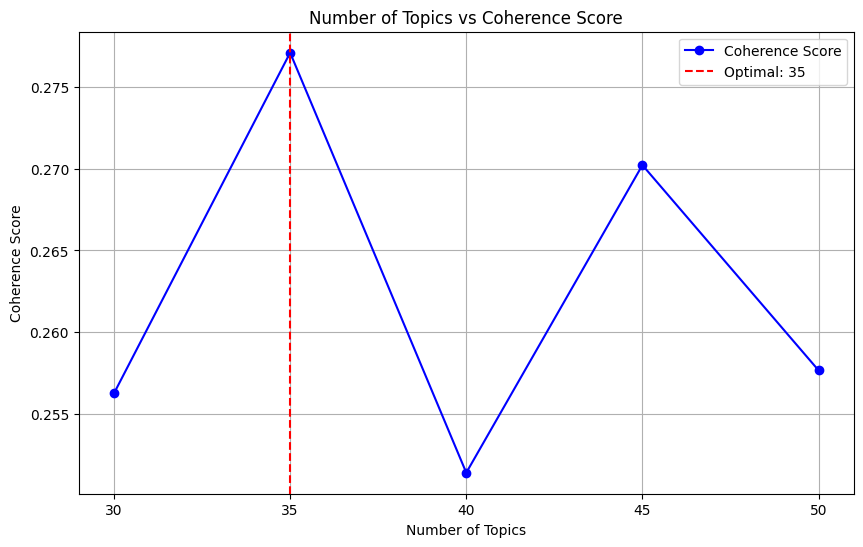

In [ ]:
# tuning number of topics and picking the one with the highest coherence

# specify range of topics
min_topics = 5
max_topics = 50
step_size = 5
topics_range = range(min_topics, max_topics + 1, step_size)

# grid search over number of topics
coherence_scores = []

for num_topics in topics_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=15,
        random_state=42
    )
    cm = CoherenceModel(
        model=lda_model,
        texts=lda_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics}, Coherence: {score:.4f}")

# find optimal
optimal_num_topics = list(topics_range)[np.argmax(coherence_scores)]
print(f"\nOptimal Number of Topics: {optimal_num_topics}")
print(f"Coherence Score: {max(coherence_scores):.4f}")

# plot
plt.figure(figsize=(10, 6))
plt.plot(topics_range, coherence_scores, marker="o", color="b", label="Coherence Score")
plt.axvline(x=optimal_num_topics, color="r", linestyle="--", label=f"Optimal: {optimal_num_topics}")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Number of Topics vs Coherence Score")
plt.xticks(topics_range)
plt.legend()
plt.grid(True)
plt.show()

## Enhanced LDA

In [ ]:
# chunk by scene since each episode can contain different plot lines
def create_chunked_corpus(df, chunk_size, text_col='text'):
    chunks = []
    for (season, episode), group in df.groupby(["season", "episode"]):
        lines = group[text_col].tolist()
        for i in range(0, len(lines), chunk_size):
            chunk = " ".join(lines[i:i+chunk_size])
            if len(chunk.split()) > 5:
                chunks.append({
                    "season": season,
                    "episode": episode,
                    "text": chunk
                })
    return pd.DataFrame(chunks)

# Create the new enhanced_lda_df
enhanced_lda_df = create_chunked_corpus(df, chunk_size=50)

print(f"Number of chunks: {len(enhanced_lda_df)}")
enhanced_lda_df.head()

Number of chunks: 1704


,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive. I can't breathe a...
1,season-1,episode-1-Pilot.json,"I will. J.P., update on the Morgenthau murder?..."
2,season-1,episode-1-Pilot.json,What the hell's goin' on around here? Fire ext...
3,season-1,episode-1-Pilot.json,I never liked that nickname. Though to be fair...
4,season-1,episode-1-Pilot.json,That was very well put. I've talked a lot abou...


In [ ]:
enhanced_stop_words = stop_words.copy()

def preprocess_for_enhanced_lda(text, stop_words):
    # make lowercase and remove punctuation
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)

    # lemmatize and filter via spaCy — nouns and adjectives only
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha
        and token.lemma_ not in stop_words
        and len(token.lemma_) > 2
        and token.lemma_ != "-PRON-"
        and token.pos_ in ("NOUN", "PROPN", "ADJ")  # restrict to nouns + adjectives
    ]
    return tokens

def use_enhanced_lda(df, stop_words=enhanced_stop_words):

  # Preprocess episodes for enhanced LDA
  enhanced_lda_docs = [preprocess_for_enhanced_lda(text, stop_words) for text in enhanced_lda_df["text"]]

  # Build bigrams
  bigram = Phrases(enhanced_lda_docs, min_count=3, threshold=5)
  bigram_mod = Phraser(bigram)

  # Build trigrams on top of bigrams
  trigram = Phrases(bigram[enhanced_lda_docs], min_count=3, threshold=5)
  trigram_mod = Phraser(trigram)

  # Apply bigrams and trigrams
  enhanced_lda_docs = [trigram_mod[bigram_mod[doc]] for doc in enhanced_lda_docs]

  return enhanced_lda_docs

# Preview
enhanced_lda_docs = use_enhanced_lda(enhanced_lda_df)
print(enhanced_lda_docs[1][:20])



ModuleNotFoundError: No module named 'gensim'

In [ ]:
# generic verbs and fillers
enhanced_stop_words.update({
    "guy", "time", "thing", "man", "way", "little",
    "bad", "day", "people", "fine", "year", "let",
    "cool", "big", "wrong", "real", "new", "nice",
    "lot", "fun", "old", "ill", "thank", "great",
    "sorry", "charle", "first", "possible", "minute",
    "hour", "hell", "weird",
})

# use the updated stop words
enhanced_lda_docs = use_enhanced_lda(enhanced_lda_df, stop_words=enhanced_stop_words)
enhanced_lda_docs[1][:20]


In [ ]:
# using tfidif


# build dictionary
enhanced_dictionary = corpora.Dictionary(enhanced_lda_docs)
enhanced_dictionary.filter_extremes(
    no_below=5,
    no_above=0.8,
    keep_n=10000
)

# build raw bow corpus
enhanced_corpus = [enhanced_dictionary.doc2bow(doc) for doc in enhanced_lda_docs]

print(f"Dictionary size: {len(enhanced_dictionary)}")
print(f"Corpus size: {len(enhanced_corpus)}")

# apply TF-IDF model
tfidf = TfidfModel(enhanced_corpus)
enhanced_corpus_tfidf = tfidf[enhanced_corpus]

Dictionary size: 3208
Corpus size: 1704


Topics: 5, Coherence: 0.2596
Topics: 10, Coherence: 0.2613
Topics: 15, Coherence: 0.3382
Topics: 20, Coherence: 0.3768
Topics: 25, Coherence: 0.4334
Topics: 30, Coherence: 0.4813
Topics: 35, Coherence: 0.4532
Topics: 40, Coherence: 0.5118
Topics: 45, Coherence: 0.5232
Topics: 50, Coherence: 0.5267
Topics: 55, Coherence: 0.4750
Topics: 60, Coherence: 0.5072


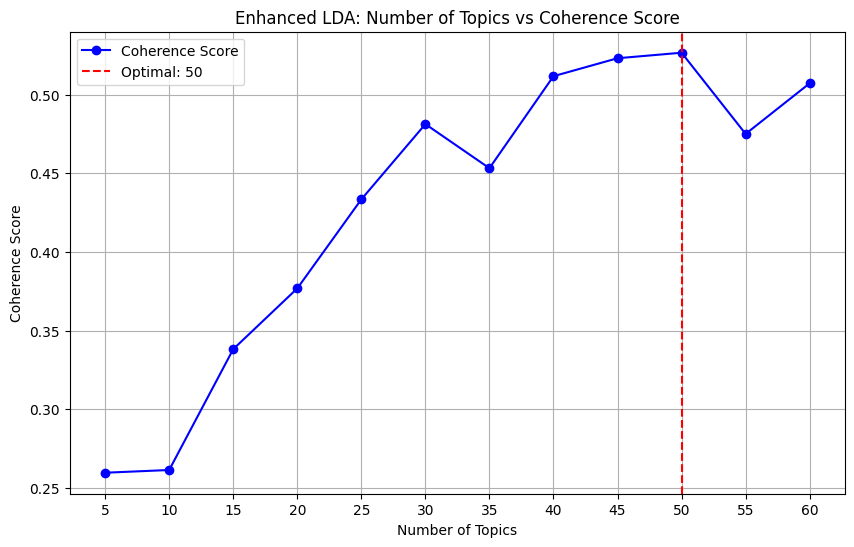

Optimal Number of Topics: 50
Best Coherence Score: 0.5267


In [ ]:
# tuning number of topics and picking the one with the highest coherence

coherence_scores = []

# specify range of topics
min_topics = 5
max_topics = 60
step_size = 5
topics_range = range(min_topics, max_topics + 1, step_size)

for num_topics in topics_range:
    lda_model = LdaModel(
        corpus=enhanced_corpus_tfidf,
        id2word=enhanced_dictionary,
        num_topics=num_topics,
        passes=10,
        alpha="auto", # letting the model choose the alpha, eta
        eta="auto",
        random_state=42
    )
    cm = CoherenceModel(
        model=lda_model,
        texts=enhanced_lda_docs,
        dictionary=enhanced_dictionary,
        coherence="c_v"
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics}, Coherence: {score:.4f}")

# Plot
optimal_num_topics_enhanced = list(topics_range)[np.argmax(coherence_scores)]

plt.figure(figsize=(10, 6))
plt.plot(topics_range, coherence_scores, marker="o", color="b", label="Coherence Score")
plt.axvline(x=optimal_num_topics_enhanced, color="r", linestyle="--",
            label=f"Optimal: {optimal_num_topics_enhanced}")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Enhanced LDA: Number of Topics vs Coherence Score")
plt.xticks(topics_range)
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {optimal_num_topics_enhanced}")
print(f"Best Coherence Score: {max(coherence_scores):.4f}")

In [ ]:
optimal_num_topics_enhanced = 30

In [ ]:
# enhanced LDA model

enhanced_lda_model = LdaModel(
    corpus=enhanced_corpus_tfidf,
    id2word=enhanced_dictionary,
    num_topics=optimal_num_topics_enhanced,
    passes=15,          # more passes for final model
    alpha="auto",
    eta="auto",
    random_state=42
)

# Preview topics
for idx, topic in enhanced_lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

final_coherence = CoherenceModel(
    model=enhanced_lda_model,
    texts=enhanced_lda_docs,
    dictionary=enhanced_dictionary,
    coherence="c_v"
).get_coherence()

print(f"Final Enhanced LDA Coherence: {final_coherence:.4f}")

Topic 18: 0.009*"muffin" + 0.008*"plaque" + 0.005*"chain" + 0.004*"cold_case" + 0.004*"student" + 0.004*"blog" + 0.004*"hawkin" + 0.004*"testicle" + 0.004*"response" + 0.003*"vasectomy"
Topic 27: 0.006*"bread" + 0.005*"curse" + 0.005*"citizen" + 0.005*"dana" + 0.004*"spider" + 0.004*"bean" + 0.004*"wint" + 0.004*"cause" + 0.004*"stranger" + 0.004*"thumb"
Topic 8: 0.006*"break_room" + 0.005*"diaper" + 0.005*"snake" + 0.005*"tail" + 0.004*"mess" + 0.004*"closet" + 0.003*"balloon_arch" + 0.003*"flaco" + 0.003*"john" + 0.003*"saturday"
Topic 29: 0.007*"mmhmm" + 0.005*"miller" + 0.005*"pink" + 0.004*"horny" + 0.004*"thankful" + 0.004*"extreme" + 0.004*"doll" + 0.004*"pontiac_bandit" + 0.004*"hoot" + 0.004*"corkscrew"
Topic 4: 0.006*"switch" + 0.005*"moose" + 0.005*"painting" + 0.004*"gift" + 0.004*"damage" + 0.004*"barrel" + 0.004*"mouse" + 0.004*"ice_cream" + 0.004*"allergy" + 0.004*"rock"
Topic 21: 0.007*"grape" + 0.006*"mother" + 0.005*"cruise" + 0.005*"boat" + 0.004*"getaway" + 0.004*"t

In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    enhanced_lda_model,
    enhanced_corpus_tfidf,
    enhanced_dictionary,
    sort_topics=False
)

pyLDAvis.display(vis)

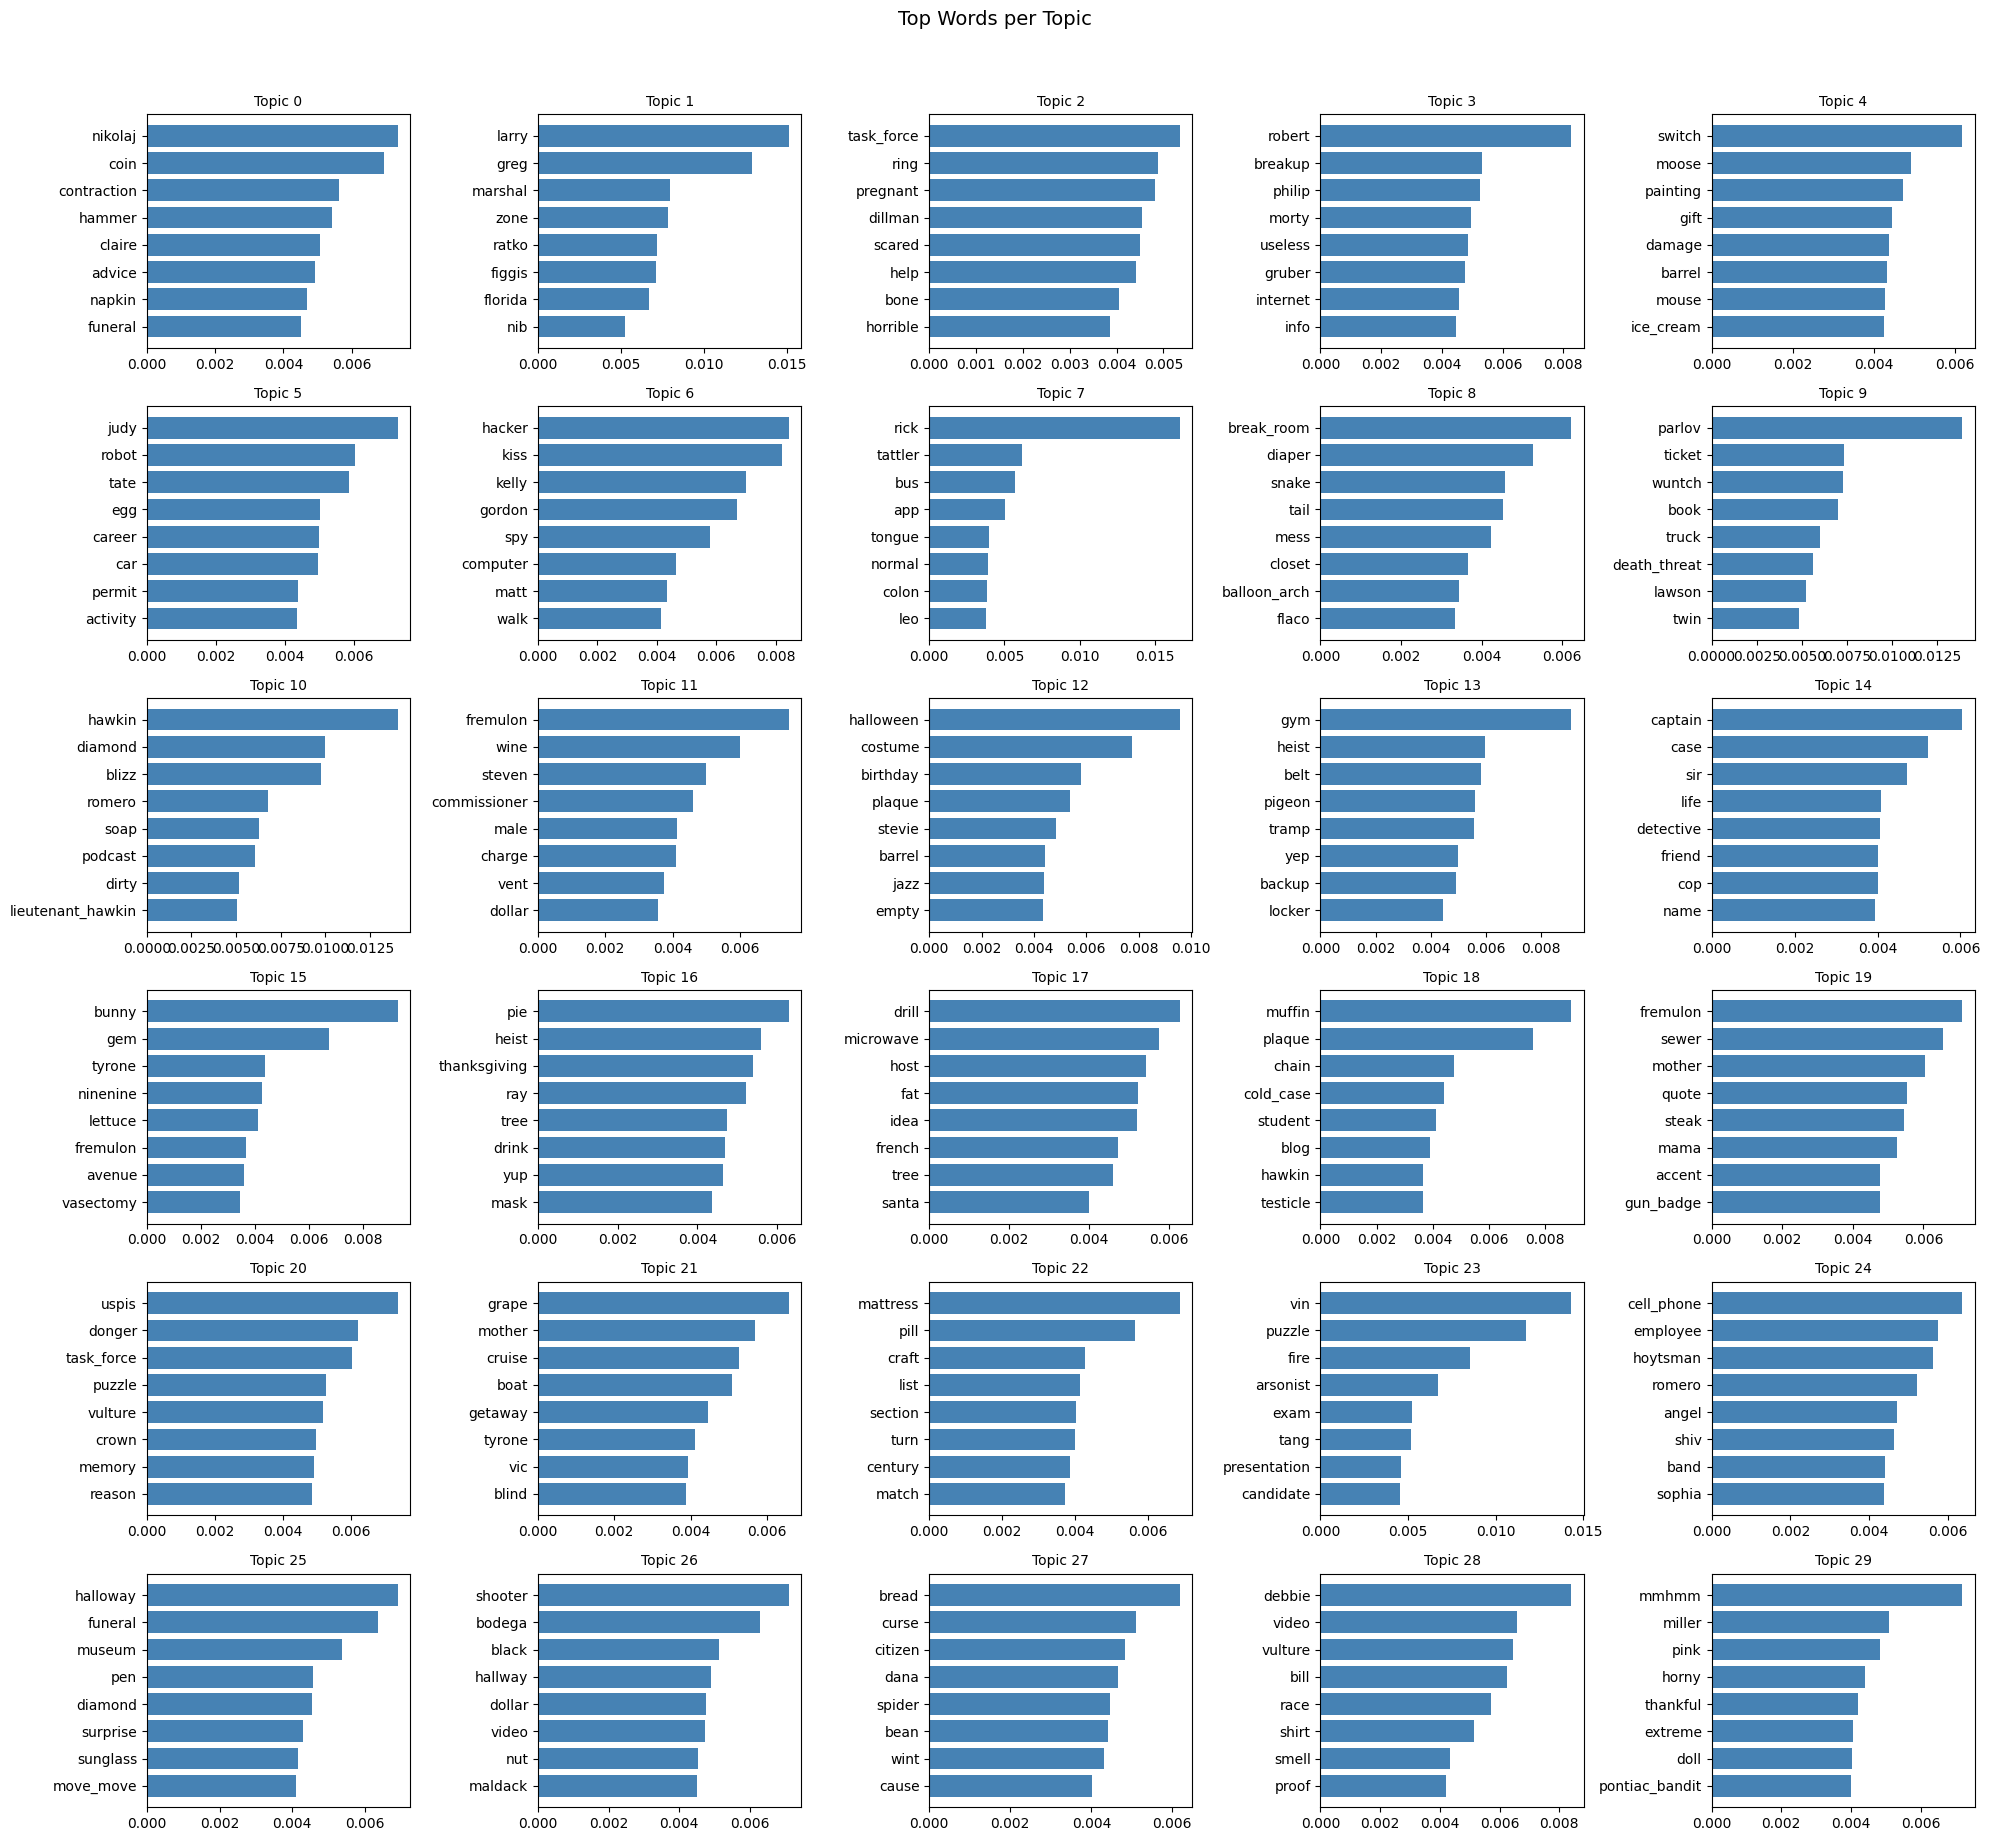

In [ ]:
def plot_top_words(model, num_topics, num_words=8, topics_per_row=5):
    num_rows = math.ceil(num_topics / topics_per_row)
    fig, axes = plt.subplots(num_rows, topics_per_row,
                              figsize=(20, num_rows * 3))
    axes = axes.flatten()

    for topic_id in range(num_topics):
        words, weights = zip(*model.show_topic(topic_id, topn=num_words))
        axes[topic_id].barh(words, weights, color="steelblue")
        axes[topic_id].set_title(f"Topic {topic_id}", fontsize=10)
        axes[topic_id].invert_yaxis()

    # hide empty subplots
    for i in range(num_topics, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle("Top Words per Topic", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("topic_words_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_top_words(enhanced_lda_model, num_topics=30)

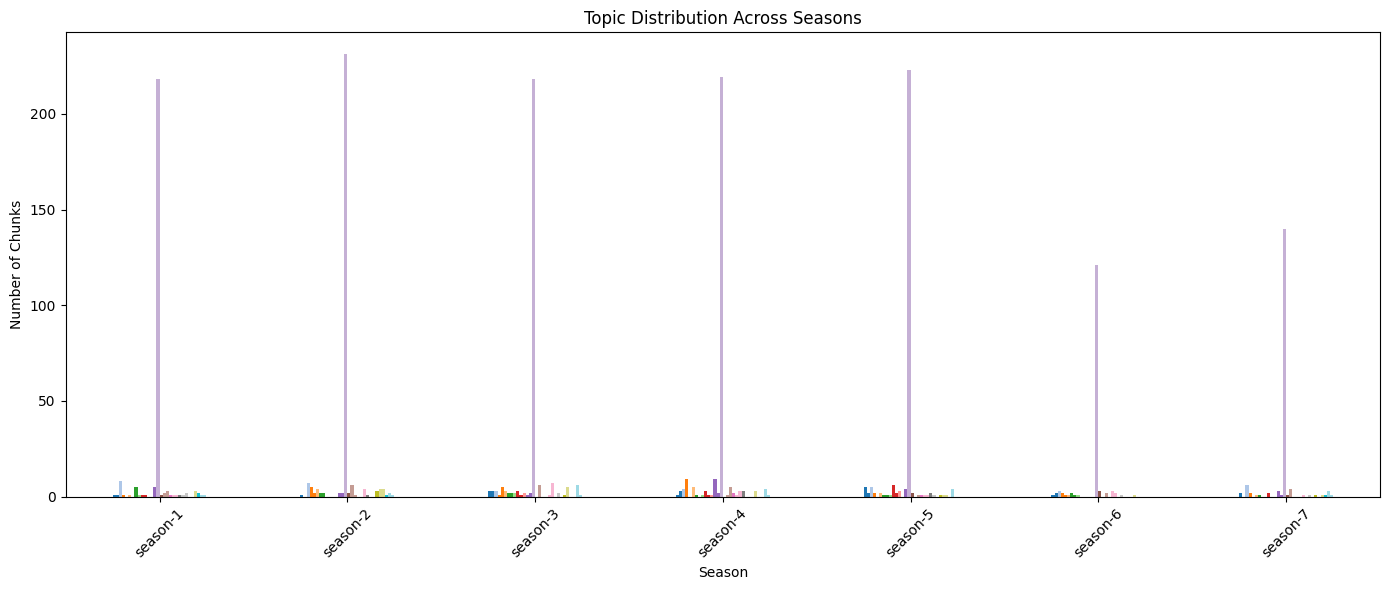

In [ ]:
# get dominant topic for each chunk
def get_dominant_topic(model, corpus):
    dominant_topics = []
    for doc_bow in corpus:
        topics = model.get_document_topics(doc_bow)
        dominant = max(topics, key=lambda x: x[1])
        dominant_topics.append(dominant[0])
    return dominant_topics

enhanced_lda_df["dominant_topic"] = get_dominant_topic(
    enhanced_lda_model, enhanced_corpus_tfidf
)

# Plot topic distribution per season
topic_season = enhanced_lda_df.groupby(["season", "dominant_topic"]).size().unstack(fill_value=0)

topic_season.plot(
    kind="bar",
    figsize=(14, 6),
    colormap="tab20",
    legend=False
)
plt.title("Topic Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("topic_season_distribution.png", dpi=300)
plt.show()

# Bertopic

For Bertopic, the best choice for the document is the use of scenes. Since the dataset does not split the text on scene natively, we experiment with chunking each document with x lines.

## Baseline

### Preprocessing

In [11]:
bertopic_df = df.copy()
bertopic_df.head()

# clean and preprocess text

FILLERS = {'um', 'uh', 'hmm', 'oh', 'ah', 'okay', 'yeah', 'hey', 'like'}

def clean_for_bertopic(text):
    text = text.lower()
    text = re.sub(r"[^\w\s']", '', text)
    tokens = [t for t in text.split() if t not in FILLERS]
    return ' '.join(tokens)

bertopic_df["clean_text"] = bertopic_df["text"].apply(clean_for_bertopic)
bertopic_df = bertopic_df[bertopic_df["clean_text"].str.split().str.len() >= 3].reset_index(drop=True)
bertopic_df.head()

bertopic_df = create_chunked_corpus(bertopic_df, chunk_size=10, text_col='clean_text')
docs = bertopic_df['text'].tolist()
print(f"Total chunks: {len(docs)}")
bertopic_df.head()

Total chunks: 7387


,season,episode,text
0,season-1,episode-1-Pilot.json,this job is eating me alive i can't breathe an...
1,season-1,episode-1-Pilot.json,so the store was hit about two hours ago they ...
2,season-1,episode-1-Pilot.json,watching learning waiting his code name fuzzy ...
3,season-1,episode-1-Pilot.json,it's time to come home i'm not sure if i can i...
4,season-1,episode-1-Pilot.json,i hate this and you're just gonna wanna add on...


### Model

In [12]:


topic_model = BERTopic(
    language="english",
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

2026-05-06 16:11:38,066 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-06 16:11:51,029 - BERTopic - Embedding - Completed ✓
2026-05-06 16:11:51,031 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 16:12:33,920 - BERTopic - Dimensionality - Completed ✓
2026-05-06 16:12:33,921 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 16:12:34,602 - BERTopic - Cluster - Completed ✓
2026-05-06 16:12:34,603 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-06 16:12:35,273 - BERTopic - Representation - Completed ✓
2026-05-06 16:12:35,275 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 16:12:35,309 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 16:12:35,933 - BERTopic - Representation - Completed ✓
2026-05-06 16:12:35,936 - BERTopic - Topic reduction - Reduced number of topics from 84 to 54


### Evaluation

In [13]:
# How many topics were found
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3880,-1_you_the_to_and,"[you, the, to, and, it, that, of, is, in, this]",[not really i don't ask people out i just tell...
1,0,1395,0_the_you_to_and,"[the, you, to, and, it, of, is, that, in, my]",[of your space really what's going on here not...
2,1,373,1_holt_captain_scully_the,"[holt, captain, scully, the, to, you, and, is,...",[wow i'm sorry i'm just trying to see if capta...
3,2,119,2_wedding_married_to_you,"[wedding, married, to, you, and, the, be, it, ...",[i suppose i can see how a balloon arch might'...
4,3,116,3_rosa_you_her_to,"[rosa, you, her, to, the, no, of, that, my, me]",[i smiled at you ladies and gentlemen widows a...
5,4,103,4_terry_you_to_the,"[terry, you, to, the, im, it, we, are, is, me]",[maybe it's all in your head bitches be crazy ...
6,5,90,5_hitchcock_the_it_is,"[hitchcock, the, it, is, its, to, hitchcocks, ...",[nothing else is working let's try it the hitc...
7,6,83,6_money_you_it_mattress,"[money, you, it, mattress, that, coin, the, to...",[well you owe all of us money so does that mea...
8,7,77,7_dad_mom_my_parents,"[dad, mom, my, parents, you, to, know, your, a...",[is my dad here no i called him and he said ho...
9,8,75,8_hitchcock_scully_and_the,"[hitchcock, scully, and, the, to, there, they,...",[hitchcock introduced me to his new goldfish w...


In [ ]:
# Top words for a specific topic
print(topic_model.get_topic(0))

# How many docs landed in the outlier topic (-1)
outlier_count = sum(t == -1 for t in topics)
total = len(topics)
print(f"Outliers: {outlier_count}/{total} ({outlier_count/total:.1%})")

[('the', np.float64(0.02281782268638627)), ('you', np.float64(0.02247783005418552)), ('to', np.float64(0.020442579199639984)), ('and', np.float64(0.01823208207272502)), ('is', np.float64(0.01655097938383242)), ('it', np.float64(0.0162217433286747)), ('of', np.float64(0.01603915373735809)), ('that', np.float64(0.015832593442378428)), ('in', np.float64(0.01506860268921153)), ('this', np.float64(0.014383811307639053))]
Outliers: 3884/7387 (52.6%)


In [ ]:
# top words for a specific topic
topic_model.get_topic(0)

[('the', np.float64(0.02281782268638627)),
 ('you', np.float64(0.02247783005418552)),
 ('to', np.float64(0.020442579199639984)),
 ('and', np.float64(0.01823208207272502)),
 ('is', np.float64(0.01655097938383242)),
 ('it', np.float64(0.0162217433286747)),
 ('of', np.float64(0.01603915373735809)),
 ('that', np.float64(0.015832593442378428)),
 ('in', np.float64(0.01506860268921153)),
 ('this', np.float64(0.014383811307639053))]

In [ ]:
# add coherence score?

## Enhanced Bertopic

1. curated stopword list
2. restrict to nouns and adjectives
3. better embedding model
4. tune hdbscan
5. add mmr for topic diversity
6. find optimal number of topics
7. fit enhanced model



In [14]:
enhanced_bertopic_df = bertopic_df.copy()
enhanced_bertopic_df

,season,episode,text
0,season-1,episode-1-Pilot.json,this job is eating me alive i can't breathe an...
1,season-1,episode-1-Pilot.json,so the store was hit about two hours ago they ...
2,season-1,episode-1-Pilot.json,watching learning waiting his code name fuzzy ...
3,season-1,episode-1-Pilot.json,it's time to come home i'm not sure if i can i...
4,season-1,episode-1-Pilot.json,i hate this and you're just gonna wanna add on...
...,...,...,...
7382,season-7,episode-9-Dillman.json,thank you for gasping at my gasp sorry you mis...
7383,season-7,episode-9-Dillman.json,as a cleaning lady in college huh i guess ther...
7384,season-7,episode-9-Dillman.json,i stormed into the other room and moped by mys...
7385,season-7,episode-9-Dillman.json,are you kidding i mean just look at today inst...


In [15]:
# only keep nouns & adjectives (parallel to LDA)
nlp.max_length = 2000000

def pos_filter(text):
    doc = nlp(text, disable=['parser', 'ner'])
    tokens = [token.lemma_ for token in doc if token.pos_ in {'NOUN', 'PROPN', 'ADJ'}]
    return ' '.join(tokens)

stop_words_list = list(stop_words)
vectorizer = CountVectorizer(
    stop_words=stop_words_list,
    tokenizer=lambda text: pos_filter(text).split(),
    min_df=2
)

In [18]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    prediction_data=True
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    random_state=42  # for reproducibility
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model_enhanced = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    nr_topics='auto',
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
# fitting the model
topics, probs = topic_model_enhanced.fit_transform(docs)

outlier_count = sum(t == -1 for t in topics)
print(f"Outliers: {outlier_count}/{len(topics)} ({outlier_count/len(topics):.1%})")
print(topic_model_enhanced.get_topic_info())

2026-05-06 16:13:49,878 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-06 16:13:56,903 - BERTopic - Embedding - Completed ✓
2026-05-06 16:13:56,904 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 16:14:23,641 - BERTopic - Dimensionality - Completed ✓
2026-05-06 16:14:23,643 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 16:14:24,022 - BERTopic - Cluster - Completed ✓
2026-05-06 16:14:24,023 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-06 16:15:02,473 - BERTopic - Representation - Completed ✓
2026-05-06 16:15:02,474 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 16:15:02,499 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 16:15:35,083 - BERTopic - Representation - Completed ✓
2026-05-06 16:15:35,086 - BERTopic - Topic reduction - Reduced number of topics from 76 to 53


Outliers: 4024/7387 (54.5%)
    Topic  Count                                     Name  \
0      -1   4024                -1_detective_name_cop_job   
1       0    943           0_commissioner_nypd_turkey_pie   
2       1    332                   1_earl_norm_fungus_gem   
3       2    279          2_captain_bum_armory_sidewinder   
4       3    194            3_wedding_marriage_venue_ring   
5       4    151            4_cliff_jocelyn_pink_universe   
6       5    108               5_claire_basic_trent_butts   
7       6     81                  6_dad_mom_parent_father   
8       7     71             7_hoot_deflect_neutral_rocky   
9       8     70               8_coin_gold_dollar_payment   
10      9     68                  9_cheddar_gem_dog_heist   
11     10     66            10_cousin_aruba_gobble_milton   
12     11     54             11_server_hacker_postal_knox   
13     12     52        12_parlov_book_skyfire_manuscript   
14     13     44  13_barnum_champion_showman_presentation

In [20]:
topic_model_enhanced.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4024,-1_detective_name_cop_job,"[detective, name, cop, job, judy, kid, friend,...",[sorry if i surprised you it's just when i was...
1,0,943,0_commissioner_nypd_turkey_pie,"[commissioner, nypd, turkey, pie, yogurt, prec...",[you're gonna go to the polish place and get p...
2,1,332,1_earl_norm_fungus_gem,"[earl, norm, fungus, gem, fred, bum, lemonade,...",[until earl slept with my wife it's not my fau...
3,2,279,2_captain_bum_armory_sidewinder,"[captain, bum, armory, sidewinder, dillman, ap...",[clear in back copy all clear on the main hall...
4,3,194,3_wedding_marriage_venue_ring,"[wedding, marriage, venue, ring, married, bach...",[guys focus we need to start planning so when'...
5,4,151,4_cliff_jocelyn_pink_universe,"[cliff, jocelyn, pink, universe, twin, veil, c...",[i'm still on second season of game of thrones...
6,5,108,5_claire_basic_trent_butts,"[claire, basic, trent, butts, adrenaline, mean...",[no not even close well keep me posted my dogs...
7,6,81,6_dad_mom_parent_father,"[dad, mom, parent, father, daddy, bi, jerry, h...",[fawning all over the golden boy i'm sure your...
8,7,71,7_hoot_deflect_neutral_rocky,"[hoot, deflect, neutral, rocky, fool, win, roo...",[or make jake feel selfconscious about his add...
9,8,70,8_coin_gold_dollar_payment,"[coin, gold, dollar, payment, loan, money, the...",[my friend are no ordinary man in fact you are...


In [ ]:
results = []
combos = [(mcs, ms) for mcs in [5, 10, 15, 20] for ms in [1, 3, 5]]
total = len(combos)

for i, (min_cluster_size, min_samples) in enumerate(combos, 1):
    print(f"[{i}/{total}] Testing min_cluster_size={min_cluster_size}, min_samples={min_samples}...", end=' ')

    hdbscan_test = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, prediction_data=True)
    test_model = BERTopic(hdbscan_model=hdbscan_test, verbose=False)
    test_topics, _ = test_model.fit_transform(docs)

    outlier_rate = sum(t == -1 for t in test_topics) / len(test_topics)
    n_topics = len(set(test_topics)) - 1
    results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'outlier_rate': round(outlier_rate, 3),
        'n_topics': n_topics
    })
    print(f"done — outlier rate: {outlier_rate:.1%}, topics found: {n_topics}")

print("\nGrid search complete!")
results_df = pd.DataFrame(results).sort_values('outlier_rate')
results_df

[1/12] Testing min_cluster_size=5, min_samples=1... 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

In [21]:
# delete once you run LDA
optimal_num_topics_enhanced = 30

In [22]:
min_cluster_size = 15
min_samples = 1

# HDBSCAN with optimal parameters from grid search
hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    prediction_data=True
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


# build the enhanced model with nr_topics matching LDA
topic_model_enhanced = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    nr_topics=optimal_num_topics_enhanced,
    verbose=True
)

topics, probs = topic_model_enhanced.fit_transform(docs)

outlier_count = sum(t == -1 for t in topics)
print(f"Outliers: {outlier_count}/{len(topics)} ({outlier_count/len(topics):.1%})")
topic_model_enhanced.get_topic_info()

2026-05-06 16:16:11,035 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-06 16:16:17,812 - BERTopic - Embedding - Completed ✓
2026-05-06 16:16:17,813 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 16:16:29,627 - BERTopic - Dimensionality - Completed ✓
2026-05-06 16:16:29,629 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 16:16:30,035 - BERTopic - Cluster - Completed ✓
2026-05-06 16:16:30,036 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-06 16:17:01,087 - BERTopic - Representation - Completed ✓
2026-05-06 16:17:01,089 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 16:17:01,130 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 16:17:34,425 - BERTopic - Representation - Completed ✓
2026-05-06 16:17:34,428 - BERTopic - Topic reduction - Reduced number of topics from 113 to 30


Outliers: 2885/7387 (39.1%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2885,-1_case_captain_cop_life,"[case, captain, cop, life, work, job, precinct...",[was the girl with the dragon tattoo well thin...
1,0,689,0_cheddar_dog_captain_kevin,"[cheddar, dog, captain, kevin, heist, gem, par...",[i can't wait to see the inside of raymond's h...
2,1,539,1_pimento_detective_drug_case,"[pimento, detective, drug, case, evidence, pri...",[we can build a puzzle around that and catch h...
3,2,493,2_wedding_dance_party_bachelor,"[wedding, dance, party, bachelor, venue, ring,...",[so you're a liar terry now no i'm no bunnybuy...
4,3,391,3_nypd_sergeant_commissioner_cop,"[nypd, sergeant, commissioner, cop, precinct, ...",[sergeant a member of the commissioner selecti...
5,4,358,4_nucci_madeline_wuntch_debbie,"[nucci, madeline, wuntch, debbie, memorial, ha...",[this service is actually real right i figured...
6,5,256,5_earl_norm_fungus_gem,"[earl, norm, fungus, gem, fred, lemonade, scar...",[ahhh gah scary witch scary so scary amy don't...
7,6,228,6_breakup_marcus_relationship_veronica,"[breakup, marcus, relationship, veronica, feel...",[peralta i will not give you a cool half mil b...
8,7,221,7_dad_pregnant_baby_daddy,"[dad, pregnant, baby, daddy, father, mom, pare...",[but i imagine it'll sober you up too aww he's...
9,8,199,8_yogurt_turkey_pie_thanksgiving,"[yogurt, turkey, pie, thanksgiving, microwave,...",[in saratoga springs raymond and i drive all t...


In [24]:
# calculating coherence

tokenized_docs = [doc.split() for doc in docs]
dictionary = corpora.Dictionary(tokenized_docs)

# extract topic words, excluding the outlier topic (-1)
topic_words = [
    [word for word, _ in topic_model_enhanced.get_topic(t)]
    for t in range(topic_model_enhanced.get_topic_info().shape[0] - 1)
]

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
)

score = coherence_model.get_coherence()
print(f"Coherence Score (c_v): {score:.4f}")

Coherence Score (c_v): 0.3988


In [25]:
# coherence model npmi
coherence_model_npmi = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_npmi'
)
print(f"BERTopic c_npmi: {coherence_model_npmi.get_coherence():.4f}")

BERTopic c_npmi: -0.2712


In [26]:
def topic_diversity(topic_words, topk=10):
    unique_words = set()
    total_words = 0
    for words in topic_words:
        unique_words.update(words[:topk])
        total_words += min(len(words), topk)
    return len(unique_words) / total_words

diversity = topic_diversity(topic_words)
print(f"Topic Diversity: {diversity:.4f}")

Topic Diversity: 0.9724


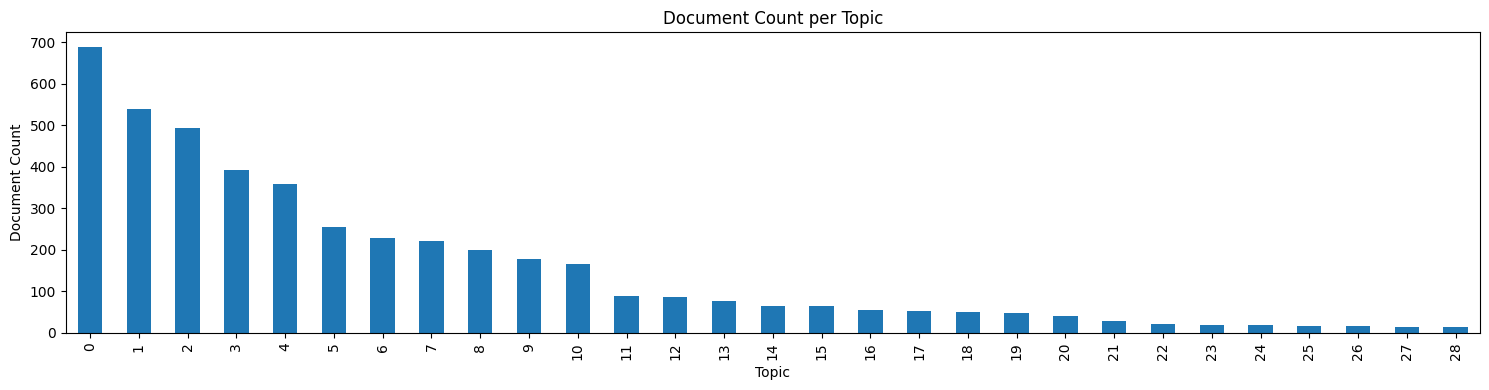

In [27]:
topic_info = topic_model_enhanced.get_topic_info()
topic_info_no_outlier = topic_info[topic_info['Topic'] != -1]

topic_info_no_outlier.plot(
    x='Topic', y='Count', kind='bar', figsize=(15, 4),
    title='Document Count per Topic', legend=False
)
plt.xlabel('Topic')
plt.ylabel('Document Count')
plt.tight_layout()
plt.show()

In [28]:
for topic_id in range(min(30, len(topic_words))):
    words = [w for w, _ in topic_model_enhanced.get_topic(topic_id)][:10]
    print(f"Topic {topic_id}: {', '.join(words)}")

Topic 0: cheddar, dog, captain, kevin, heist, gem, party, crazy, husband, friend
Topic 1: pimento, detective, drug, case, evidence, prison, witness, file, tyrone, murder
Topic 2: wedding, dance, party, bachelor, venue, ring, tonight, urine, marriage, toilet
Topic 3: nypd, sergeant, commissioner, cop, precinct, officer, committee, police, captain, squad
Topic 4: nucci, madeline, wuntch, debbie, memorial, hawkin, cliff, fbi, woman, samantha
Topic 5: earl, norm, fungus, gem, fred, lemonade, scary, pig, mouse, useless
Topic 6: breakup, marcus, relationship, veronica, feeling, jocelyn, love, text, girlfriend, phone
Topic 7: dad, pregnant, baby, daddy, father, mom, parent, kid, birth, toy
Topic 8: yogurt, turkey, pie, thanksgiving, microwave, stroller, pizza, food, diet, delicious
Topic 9: truck, car, santa, ho, van, york, fire, christmas, turpentine, flight
Topic 10: dentist, doctor, belt, thumb, equal, tooth, dental, mump, key, robert
Topic 11: lint, canvas, halloween, binder, genevieve, c

In [29]:
model = SentenceTransformer('all-MiniLM-L6-v2')

def embedding_coherence(topic_words, model):
    scores = []
    for words in topic_words:
        if len(words) < 2:
            continue
        embeddings = model.encode(words)
        # average pairwise cosine similarity
        sim_matrix = np.inner(embeddings, embeddings)
        n = len(words)
        score = (sim_matrix.sum() - n) / (n * (n - 1))  # exclude diagonal
        scores.append(score)
    return np.mean(scores)

emb_coherence = embedding_coherence(topic_words, embedding_model)
print(f"Embedding Coherence: {emb_coherence:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Coherence: 0.2997
